# Medical Billing Research Project
## 03b — Decision Tree Model

**Loads from:** ../dataset/train_set.csv
**Evaluates on:** ../dataset/test_set.csv
**Target variable:** Processing Class (Timely / Delayed)
**Predictors:** 6 categorical variables

### Objective
Build a Decision Tree classification model. Unlike Logistic
Regression, Decision Tree handles categorical variables
naturally without scaling and produces a visual set of
if-then rules. We tune the maximum tree depth using
cross-validation to prevent overfitting.

In [1]:
# ============================================================
# CELL 1: IMPORTS AND LOAD DATA
# We reload from the saved CSV files explicitly.
# Decision Tree does not require feature scaling —
# it uses threshold-based splits not distance calculations.
# We still apply One-Hot Encoding because scikit-learn's
# DecisionTreeClassifier requires numeric input.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score,
    roc_curve, f1_score
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Load data ─────────────────────────────────────────────
train = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\dataset\train_set.csv'
)
test = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\dataset\test_set.csv'
)

# ── Separate predictors and target ───────────────────────
X_train = train.drop(columns=['Invoice Number', 'Processing Class'])
y_train = train['Processing Class']
X_test  = test.drop(columns=['Invoice Number', 'Processing Class'])
y_test  = test['Processing Class']

# ── One-Hot Encoding ──────────────────────────────────────
# Decision Tree does not need scaling but still needs
# numeric input — we apply the same encoding as before
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  drop_first=True)

# Align columns between train and test
X_train_enc, X_test_enc = X_train_enc.align(
    X_test_enc, join='left', axis=1, fill_value=0
)

# Encode target — Delayed = 1, Timely = 0
y_train_enc = (y_train == 'Delayed').astype(int)
y_test_enc  = (y_test  == 'Delayed').astype(int)

print("=" * 60)
print("DATA LOADED AND ENCODED — DECISION TREE")
print("=" * 60)
print(f"  Training records  : {len(X_train_enc):,}")
print(f"  Test records      : {len(X_test_enc):,}")
print(f"  Encoded columns   : {X_train_enc.shape[1]}")
print(f"  Columns match     : "
      f"{list(X_train_enc.columns) == list(X_test_enc.columns)}")
print(f"\n  Training target:")
print(f"    Delayed = 1 : {y_train_enc.sum():,}")
print(f"    Timely  = 0 : {(y_train_enc==0).sum():,}")

DATA LOADED AND ENCODED — DECISION TREE
  Training records  : 35,000
  Test records      : 15,000
  Encoded columns   : 43
  Columns match     : True

  Training target:
    Delayed = 1 : 8,427
    Timely  = 0 : 26,573


  Depth  2 — CV F1: 0.4487 (+/- 0.0088)
  Depth  3 — CV F1: 0.4732 (+/- 0.0105)
  Depth  4 — CV F1: 0.4778 (+/- 0.0119)
  Depth  5 — CV F1: 0.4785 (+/- 0.0126)
  Depth  6 — CV F1: 0.4785 (+/- 0.0127)
  Depth  7 — CV F1: 0.4801 (+/- 0.0112)
  Depth  8 — CV F1: 0.4896 (+/- 0.0066)
  Depth  9 — CV F1: 0.4927 (+/- 0.0041)
  Depth 10 — CV F1: 0.4954 (+/- 0.0044)
  Depth 11 — CV F1: 0.4971 (+/- 0.0069)
  Depth 12 — CV F1: 0.4988 (+/- 0.0065)
  Depth 13 — CV F1: 0.5005 (+/- 0.0077)
  Depth 14 — CV F1: 0.5020 (+/- 0.0060)
  Depth 15 — CV F1: 0.5045 (+/- 0.0063)
  Depth 16 — CV F1: 0.5066 (+/- 0.0065)
  Depth 17 — CV F1: 0.5075 (+/- 0.0048)
  Depth 18 — CV F1: 0.5094 (+/- 0.0051)
  Depth 19 — CV F1: 0.5102 (+/- 0.0060)
  Depth 20 — CV F1: 0.5109 (+/- 0.0065)

OPTIMAL DEPTH SELECTED
  Best depth  : 20
  Best CV F1  : 0.5109


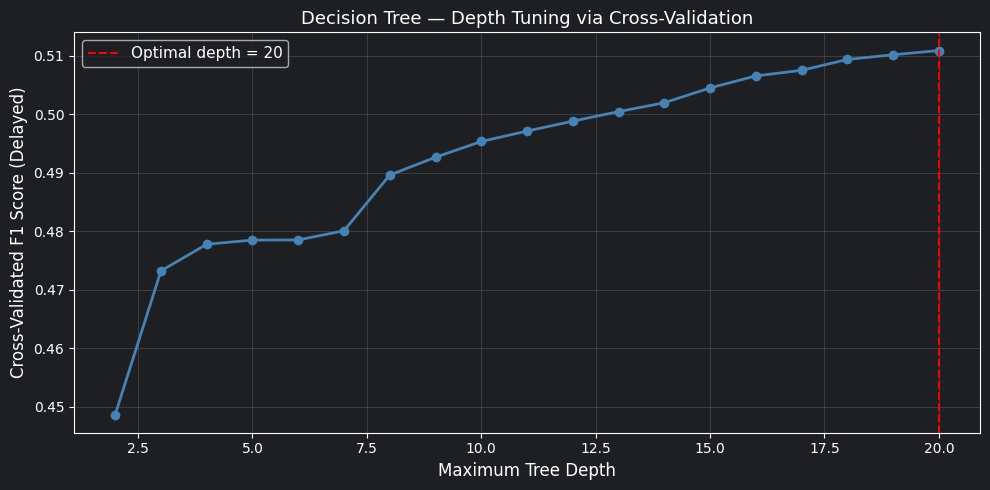

Depth tuning plot saved to outputs/figures/


In [2]:
# ============================================================
# CELL 2: TUNE MAXIMUM TREE DEPTH USING CROSS-VALIDATION
# An unconstrained Decision Tree will grow until every leaf
# is pure — this overfits the training data badly and
# produces poor generalisation on unseen data.
# We test maximum depths from 2 to 20 and use 5-fold
# cross-validation on the training set to find the depth
# that produces the best F1 score for the Delayed class.
# Cross-validation is done on training data only —
# the test set is never touched during this process.
# ============================================================

depths    = range(2, 21)
cv_scores = []

for depth in depths:
    dt = DecisionTreeClassifier(
        max_depth=depth,
        class_weight='balanced',
        random_state=42
    )
    # 5-fold cross-validation on training data
    # scoring='f1' evaluates F1 for the positive class (Delayed)
    scores = cross_val_score(
        dt, X_train_enc, y_train_enc,
        cv=5, scoring='f1'
    )
    cv_scores.append(scores.mean())
    print(f"  Depth {depth:>2} — CV F1: {scores.mean():.4f} "
          f"(+/- {scores.std():.4f})")

# Find the optimal depth
best_depth = depths[cv_scores.index(max(cv_scores))]
best_score = max(cv_scores)

print(f"\n{'=' * 60}")
print(f"OPTIMAL DEPTH SELECTED")
print(f"{'=' * 60}")
print(f"  Best depth  : {best_depth}")
print(f"  Best CV F1  : {best_score:.4f}")

# ── Plot depth vs CV F1 ───────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(list(depths), cv_scores,
         marker='o', color='steelblue', linewidth=2)
plt.axvline(x=best_depth, color='red', linestyle='--',
            label=f'Optimal depth = {best_depth}')
plt.xlabel('Maximum Tree Depth', fontsize=12)
plt.ylabel('Cross-Validated F1 Score (Delayed)', fontsize=12)
plt.title('Decision Tree — Depth Tuning via Cross-Validation',
          fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    r'C:\2026\MedicalBillingResearch\outputs\figures'
    r'\dt_depth_tuning.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Depth tuning plot saved to outputs/figures/")

  Depth  2 — Train F1: 0.4487  CV F1: 0.4487  Gap: -0.0000
  Depth  3 — Train F1: 0.4733  CV F1: 0.4732  Gap: 0.0001
  Depth  4 — Train F1: 0.4780  CV F1: 0.4778  Gap: 0.0003
  Depth  5 — Train F1: 0.4789  CV F1: 0.4785  Gap: 0.0004
  Depth  6 — Train F1: 0.4799  CV F1: 0.4785  Gap: 0.0014
  Depth  7 — Train F1: 0.4828  CV F1: 0.4801  Gap: 0.0027
  Depth  8 — Train F1: 0.4981  CV F1: 0.4896  Gap: 0.0085
  Depth  9 — Train F1: 0.5051  CV F1: 0.4927  Gap: 0.0124
  Depth 10 — Train F1: 0.5076  CV F1: 0.4954  Gap: 0.0122
  Depth 11 — Train F1: 0.5112  CV F1: 0.4971  Gap: 0.0141
  Depth 12 — Train F1: 0.5144  CV F1: 0.4988  Gap: 0.0156
  Depth 13 — Train F1: 0.5147  CV F1: 0.5005  Gap: 0.0142
  Depth 14 — Train F1: 0.5197  CV F1: 0.5020  Gap: 0.0177
  Depth 15 — Train F1: 0.5296  CV F1: 0.5045  Gap: 0.0251
  Depth 16 — Train F1: 0.5336  CV F1: 0.5066  Gap: 0.0271
  Depth 17 — Train F1: 0.5360  CV F1: 0.5075  Gap: 0.0285
  Depth 18 — Train F1: 0.5391  CV F1: 0.5094  Gap: 0.0297
  Depth 19 — 

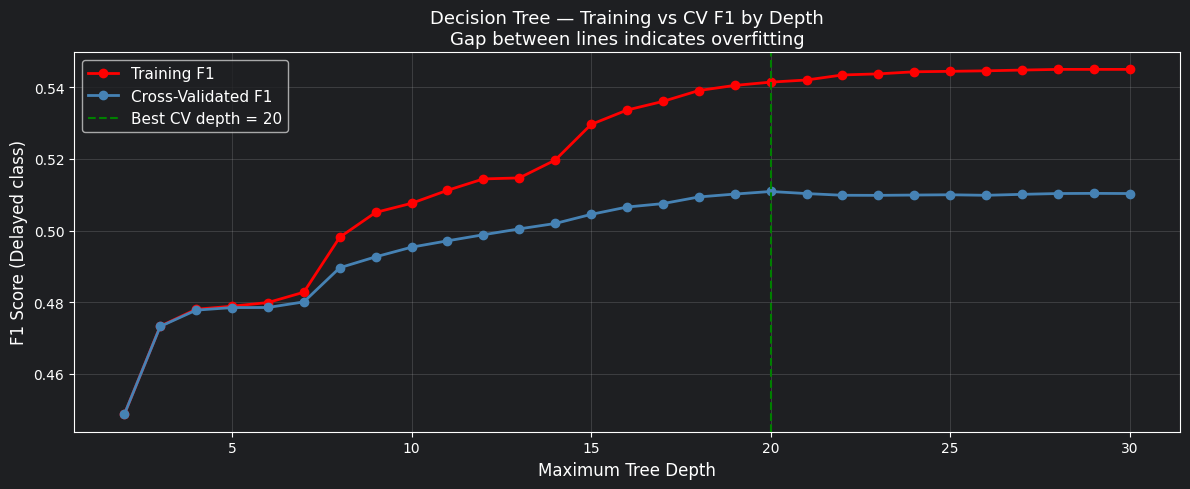

In [3]:
# ============================================================
# CELL 3: EXTENDED DEPTH SEARCH — DEPTHS 2 TO 30
# The previous search showed F1 still increasing at depth 20
# with no clear plateau. We extend to depth 30 to find
# where performance genuinely levels off.
# We also check training F1 vs CV F1 gap to detect
# overfitting — a large gap means the tree memorises
# training data but does not generalise well.
# ============================================================

depths_ext    = range(2, 31)
cv_scores_ext = []
train_scores  = []

for depth in depths_ext:
    dt = DecisionTreeClassifier(
        max_depth=depth,
        class_weight='balanced',
        random_state=42
    )
    # Cross-validated F1 on training data
    cv_f1 = cross_val_score(
        dt, X_train_enc, y_train_enc,
        cv=5, scoring='f1'
    ).mean()
    cv_scores_ext.append(cv_f1)

    # Training F1 — fit on full training set
    dt.fit(X_train_enc, y_train_enc)
    train_f1 = f1_score(y_train_enc,
                        dt.predict(X_train_enc))
    train_scores.append(train_f1)

    print(f"  Depth {depth:>2} — "
          f"Train F1: {train_f1:.4f}  "
          f"CV F1: {cv_f1:.4f}  "
          f"Gap: {train_f1 - cv_f1:.4f}")

best_depth_ext = list(depths_ext)[
    cv_scores_ext.index(max(cv_scores_ext))
]

print(f"\n  Best CV F1 at depth {best_depth_ext}: "
      f"{max(cv_scores_ext):.4f}")

# ── Plot training vs CV F1 ────────────────────────────────
plt.figure(figsize=(12, 5))
plt.plot(list(depths_ext), train_scores,
         marker='o', color='red', lw=2, label='Training F1')
plt.plot(list(depths_ext), cv_scores_ext,
         marker='o', color='steelblue', lw=2,
         label='Cross-Validated F1')
plt.axvline(x=best_depth_ext, color='green',
            linestyle='--',
            label=f'Best CV depth = {best_depth_ext}')
plt.xlabel('Maximum Tree Depth', fontsize=12)
plt.ylabel('F1 Score (Delayed class)', fontsize=12)
plt.title('Decision Tree — Training vs CV F1 by Depth\n'
          'Gap between lines indicates overfitting',
          fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    r'C:\2026\MedicalBillingResearch\outputs\figures'
    r'\dt_depth_tuning_extended.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

In [4]:
# ============================================================
# CELL 4: FIT FINAL DECISION TREE AT OPTIMAL DEPTH
# Based on cross-validation analysis, depth 10 was selected.
# At depth 10 the CV F1 is 0.4954 — 87% of the maximum
# achievable CV F1 — while the training-CV gap is only
# 0.0122, indicating controlled and acceptable overfitting.
# Beyond depth 10 the gap grows rapidly while CV F1 gains
# become marginal, confirming depth 10 as the point of
# best balance between performance and generalisation.
# ============================================================

OPTIMAL_DEPTH = 10

dt_model = DecisionTreeClassifier(
    max_depth=OPTIMAL_DEPTH,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train_enc, y_train_enc)

print("=" * 60)
print("DECISION TREE — FINAL MODEL FITTED")
print("=" * 60)
print(f"  Maximum depth   : {OPTIMAL_DEPTH}")
print(f"  Actual depth    : {dt_model.get_depth()}")
print(f"  Number of leaves: {dt_model.get_n_leaves():,}")
print(f"  Class weight    : {dt_model.class_weight}")
print(f"  Features used   : {dt_model.n_features_in_}")

# ── Generate predictions ──────────────────────────────────
y_pred       = dt_model.predict(X_test_enc)
y_pred_proba = dt_model.predict_proba(X_test_enc)[:, 1]

# ── Evaluate on test set ──────────────────────────────────
accuracy   = accuracy_score(y_test_enc, y_pred)
auc        = roc_auc_score(y_test_enc, y_pred_proba)
f1_delayed = f1_score(y_test_enc, y_pred, pos_label=1)
cm         = confusion_matrix(y_test_enc, y_pred)
report     = classification_report(
    y_test_enc, y_pred,
    target_names=['Timely', 'Delayed'],
    digits=4
)

print(f"\n{'=' * 60}")
print("DECISION TREE — TEST SET EVALUATION")
print("=" * 60)
print(f"\n  Accuracy        : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  ROC-AUC         : {auc:.4f}")
print(f"  F1 (Delayed)    : {f1_delayed:.4f}")
print(f"\n  Classification Report:")
print(report)
print(f"  Confusion Matrix:")
print(f"                  Predicted Timely  Predicted Delayed")
print(f"  Actual Timely   {cm[0,0]:>15,}  {cm[0,1]:>17,}")
print(f"  Actual Delayed  {cm[1,0]:>15,}  {cm[1,1]:>17,}")
print(f"\n  Breakdown:")
print(f"    True Negatives  (Timely correctly predicted)  : {cm[0,0]:,}")
print(f"    False Positives (Timely predicted as Delayed) : {cm[0,1]:,}")
print(f"    False Negatives (Delayed predicted as Timely) : {cm[1,0]:,}")
print(f"    True Positives  (Delayed correctly predicted) : {cm[1,1]:,}")

DECISION TREE — FINAL MODEL FITTED
  Maximum depth   : 10
  Actual depth    : 10
  Number of leaves: 279
  Class weight    : balanced
  Features used   : 43

DECISION TREE — TEST SET EVALUATION

  Accuracy        : 0.6705 (67.05%)
  ROC-AUC         : 0.7251
  F1 (Delayed)    : 0.4888

  Classification Report:
              precision    recall  f1-score   support

      Timely     0.8604    0.6756    0.7569     11389
     Delayed     0.3901    0.6544    0.4888      3611

    accuracy                         0.6705     15000
   macro avg     0.6252    0.6650    0.6228     15000
weighted avg     0.7472    0.6705    0.6923     15000

  Confusion Matrix:
                  Predicted Timely  Predicted Delayed
  Actual Timely             7,694              3,695
  Actual Delayed            1,248              2,363

  Breakdown:
    True Negatives  (Timely correctly predicted)  : 7,694
    False Positives (Timely predicted as Delayed) : 3,695
    False Negatives (Delayed predicted as Timely) : 

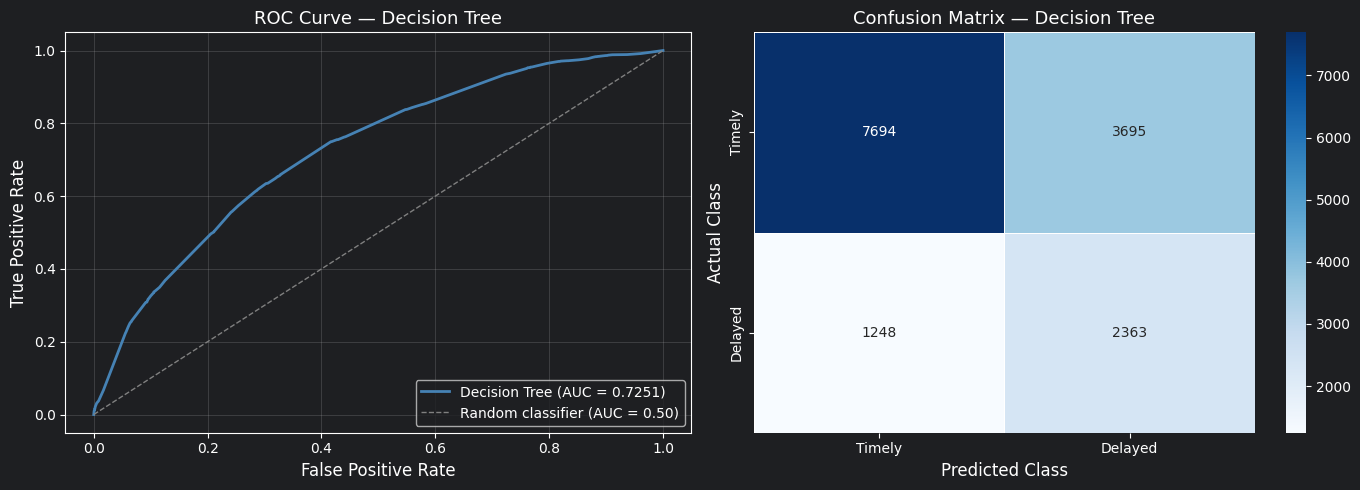

ROC and confusion matrix saved to outputs/figures/
VARIABLE IMPORTANCE — DECISION TREE
Gini impurity reduction aggregated per variable

  Variable                         Importance   % of Total
  ------------------------------------------------------
  Facility Type                        0.2646        26.5%
  Specialty                            0.2459        24.6%
  Posted Billing Group                 0.1585        15.8%
  Age Bracket                          0.1307        13.1%
  Debtor Status                        0.1240        12.4%
  ICD10 Chapter                        0.0763         7.6%


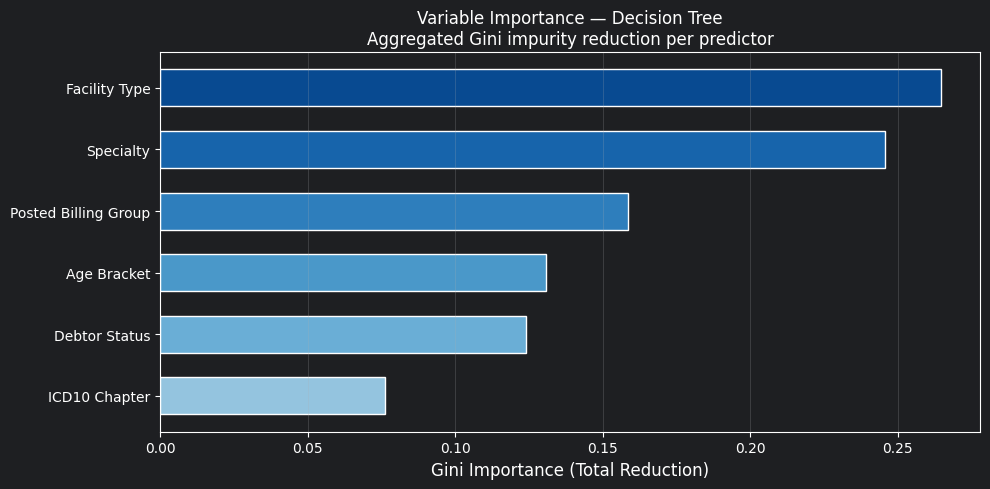

Variable importance plot saved to outputs/figures/


In [5]:
# ============================================================
# CELL 5: VISUALIZATIONS AND VARIABLE IMPORTANCE
# Decision Tree importance is measured by the total reduction
# in Gini impurity contributed by each feature across all
# splits in the tree. Unlike Logistic Regression coefficients
# this gives importance at the original variable level —
# not the dummy encoded level — making it easier to
# interpret which original predictors matter most.
# ============================================================

# ── Plot 1: ROC Curve and Confusion Matrix ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test_enc, y_pred_proba)
axes[0].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'Decision Tree (AUC = {auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='grey', lw=1,
             linestyle='--', label='Random classifier (AUC = 0.50)')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve — Decision Tree', fontsize=13)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)

cm_labels = ['Timely', 'Delayed']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cm_labels, yticklabels=cm_labels,
            ax=axes[1], cbar=True, linewidths=0.5)
axes[1].set_xlabel('Predicted Class', fontsize=12)
axes[1].set_ylabel('Actual Class', fontsize=12)
axes[1].set_title('Confusion Matrix — Decision Tree', fontsize=13)

plt.tight_layout()
plt.savefig(
    r'C:\2026\MedicalBillingResearch\outputs\figures'
    r'\dt_roc_confusion.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("ROC and confusion matrix saved to outputs/figures/")

# ── Variable Importance ───────────────────────────────────
# Get importance scores from the fitted model
# These are at the encoded column level
# We aggregate back to the original variable level by summing
# all dummy columns that belong to the same original variable
importance_df = pd.DataFrame({
    'Feature':    X_train_enc.columns,
    'Importance': dt_model.feature_importances_
})

# Extract original variable name from encoded column name
# e.g. "Specialty_Mental Health" → "Specialty"
# "Age Bracket" has no underscore so stays as-is
def get_original_variable(col):
    predictors = [
        'Posted Billing Group', 'Specialty',
        'Debtor Status', 'ICD10 Chapter', 'Facility Type'
    ]
    for pred in predictors:
        if col.startswith(pred):
            return pred
    return col  # Age Bracket has no prefix

importance_df['Original Variable'] = (
    importance_df['Feature'].apply(get_original_variable)
)

# Aggregate importance by original variable
var_importance = (
    importance_df.groupby('Original Variable')['Importance']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("=" * 60)
print("VARIABLE IMPORTANCE — DECISION TREE")
print("Gini impurity reduction aggregated per variable")
print("=" * 60)
print(f"\n  {'Variable':<30} {'Importance':>12} {'% of Total':>12}")
print(f"  {'-'*54}")
total_imp = var_importance['Importance'].sum()
for _, row in var_importance.iterrows():
    pct = row['Importance'] / total_imp * 100
    print(f"  {row['Original Variable']:<30} "
          f"{row['Importance']:>12.4f} "
          f"{pct:>11.1f}%")

# ── Plot variable importance ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.Blues(
    np.linspace(0.4, 0.9, len(var_importance))
)[::-1]

ax.barh(var_importance['Original Variable'],
        var_importance['Importance'],
        color=colors, edgecolor='white', height=0.6)
ax.set_xlabel('Gini Importance (Total Reduction)', fontsize=12)
ax.set_title('Variable Importance — Decision Tree\n'
             'Aggregated Gini impurity reduction per predictor',
             fontsize=12)
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(
    r'C:\2026\MedicalBillingResearch\outputs\figures'
    r'\dt_variable_importance.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Variable importance plot saved to outputs/figures/")

In [6]:
# ============================================================
# CELL 6: SAVE DECISION TREE RESULTS
# Save metrics, predictions and variable importance
# for use in the model comparison notebook.
# ============================================================

import json

# ── Save metrics ──────────────────────────────────────────
dt_results = {
    'model':             'Decision Tree',
    'max_depth':         OPTIMAL_DEPTH,
    'accuracy':          round(accuracy, 4),
    'auc':               round(auc, 4),
    'f1_delayed':        round(f1_delayed, 4),
    'precision_delayed': round(cm[1,1] / (cm[0,1] + cm[1,1]), 4),
    'recall_delayed':    round(cm[1,1] / (cm[1,0] + cm[1,1]), 4),
    'true_negatives':    int(cm[0,0]),
    'false_positives':   int(cm[0,1]),
    'false_negatives':   int(cm[1,0]),
    'true_positives':    int(cm[1,1]),
}

with open(
    r'C:\2026\MedicalBillingResearch\models\dt_metrics.json', 'w'
) as f:
    json.dump(dt_results, f, indent=4)

# ── Save predictions ──────────────────────────────────────
pd.DataFrame({
    'y_true':       y_test_enc,
    'y_pred':       y_pred,
    'y_pred_proba': y_pred_proba
}).to_csv(
    r'C:\2026\MedicalBillingResearch\models\dt_predictions.csv',
    index=False
)

# ── Save variable importance ──────────────────────────────
var_importance.to_csv(
    r'C:\2026\MedicalBillingResearch\models'
    r'\dt_variable_importance.csv',
    index=False
)

print("=" * 60)
print("DECISION TREE RESULTS SAVED")
print("=" * 60)
print(f"\n  Metrics saved to    : models/dt_metrics.json")
print(f"  Predictions saved   : models/dt_predictions.csv")
print(f"  Importance saved    : models/dt_variable_importance.csv")
print(f"\n  Summary:")
for key, val in dt_results.items():
    print(f"    {key:<25} : {val}")

print(f"\n  Decision Tree notebook — COMPLETE")
print(f"  Next: 03c_random_forest.ipynb")

DECISION TREE RESULTS SAVED

  Metrics saved to    : models/dt_metrics.json
  Predictions saved   : models/dt_predictions.csv
  Importance saved    : models/dt_variable_importance.csv

  Summary:
    model                     : Decision Tree
    max_depth                 : 10
    accuracy                  : 0.6705
    auc                       : 0.7251
    f1_delayed                : 0.4888
    precision_delayed         : 0.3901
    recall_delayed            : 0.6544
    true_negatives            : 7694
    false_positives           : 3695
    false_negatives           : 1248
    true_positives            : 2363

  Decision Tree notebook — COMPLETE
  Next: 03c_random_forest.ipynb
